In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
data = pd.read_csv(r"seattle-weather.csv")
data.head()

,date,precipitation,temp_max,temp_min,wind,weather
0,2012-01-01,0.0,12.8,5.0,4.7,drizzle
1,2012-01-02,10.9,10.6,2.8,4.5,rain
2,2012-01-03,0.8,11.7,7.2,2.3,rain
3,2012-01-04,20.3,12.2,5.6,4.7,rain
4,2012-01-05,1.3,8.9,2.8,6.1,rain


<Axes: >

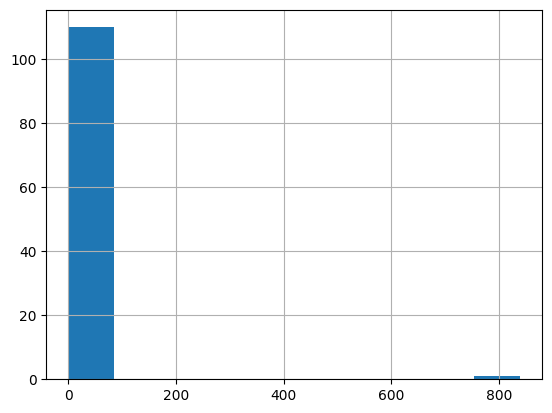

In [9]:
data.precipitation.value_counts().hist(bins=10)

<Axes: xlabel='weather', ylabel='count'>

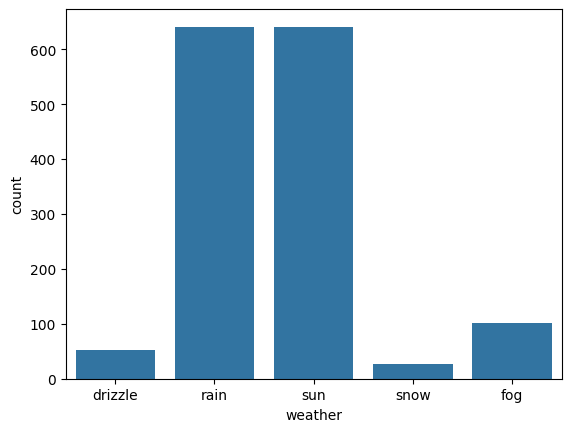

In [7]:
sns.countplot(x='weather', data=data)

<Axes: xlabel='weather', ylabel='precipitation'>

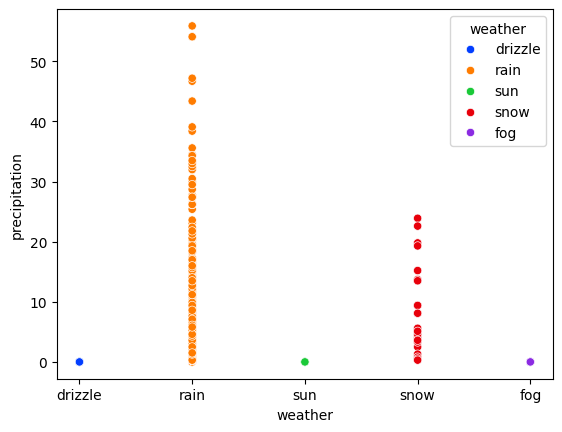

In [10]:
sns.scatterplot(x='weather', y='precipitation', data=data, palette='bright',hue='weather')

<Axes: ylabel='temp_min'>

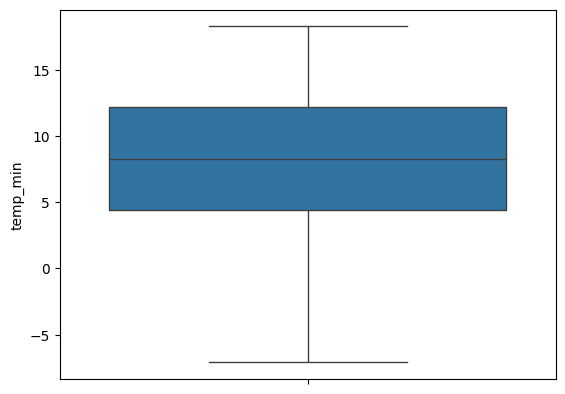

In [11]:
sns.boxplot(y='temp_min', data=data)

<Axes: xlabel='weather', ylabel='precipitation'>

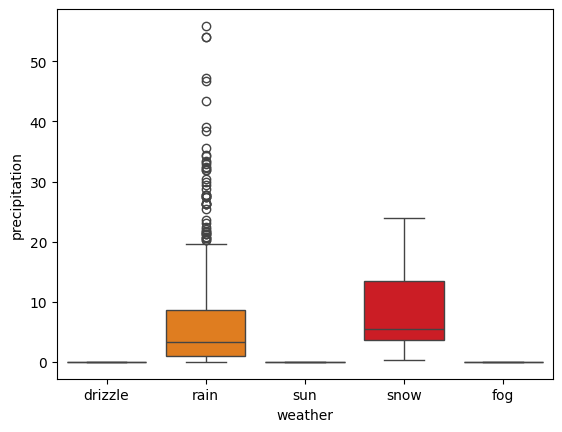

In [14]:
sns.boxplot(y='precipitation', data=data, x='weather', palette='bright', hue='weather')

<Axes: xlabel='weather', ylabel='temp_max'>

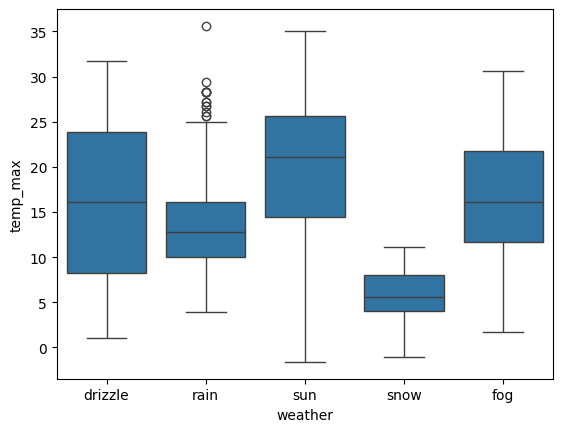

In [17]:
sns.boxplot(y='temp_max', data=data, x='weather')

<Axes: xlabel='weather', ylabel='temp_min'>

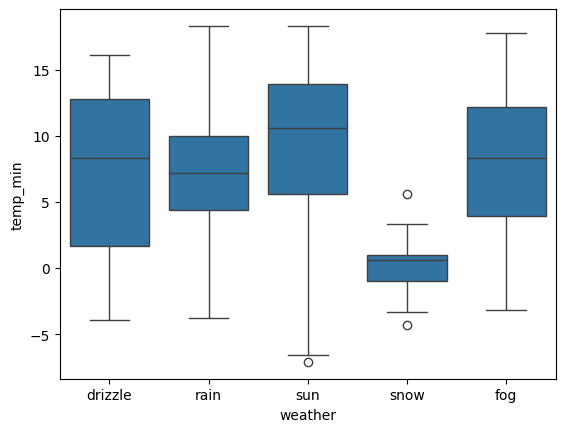

In [18]:
sns.boxplot(y='temp_min', data=data, x='weather')

<Axes: xlabel='wind', ylabel='Count'>

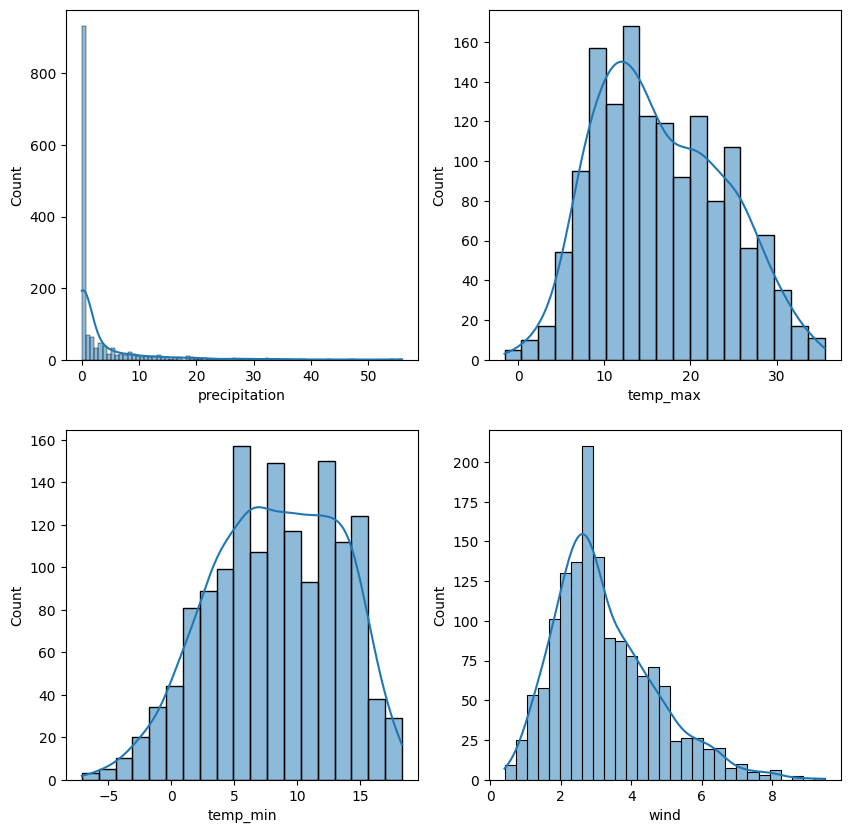

In [21]:
fig , axes = plt.subplots(2,2, figsize=(10,10))
sns.histplot(x='precipitation', kde=True, data=data, ax=axes[0,0])
sns.histplot(x='temp_max', kde=True, data=data, ax=axes[0,1])
sns.histplot(x='temp_min', kde=True, data=data, ax=axes[1,0])
sns.histplot(x='wind', kde=True, data=data, ax=axes[1,1])

In [10]:
# get X, y parameters
data.head(2)

,date,precipitation,temp_max,temp_min,wind,weather
0,2012-01-01,0.0,12.8,5.0,4.7,drizzle
1,2012-01-02,10.9,10.6,2.8,4.5,rain


In [11]:
X = data.drop(columns=['date','weather'])
X.head(2)

,precipitation,temp_max,temp_min,wind
0,0.0,12.8,5.0,4.7
1,10.9,10.6,2.8,4.5


In [12]:
y = data['weather']
y.head(2)

0    drizzle
1       rain
Name: weather, dtype: str

In [13]:
# encoding to 'weather' column, 
# do manual encoding
enc_weather = {'drizzle':0,'rain':1,'sun':2,'snow':3,'fog':4}
y = data.weather.map(enc_weather)
y

0       0
1       1
2       1
3       1
4       1
       ..
1456    1
1457    1
1458    4
1459    2
1460    2
Name: weather, Length: 1461, dtype: int64

In [14]:
data.head(2)

,date,precipitation,temp_max,temp_min,wind,weather
0,2012-01-01,0.0,12.8,5.0,4.7,drizzle
1,2012-01-02,10.9,10.6,2.8,4.5,rain


In [15]:

y.head()

0    0
1    1
2    1
3    1
4    1
Name: weather, dtype: int64

In [28]:
from sklearn.model_selection import train_test_split


In [29]:
X_train, X_test,y_train,y_test = train_test_split(X,y,test_size=0.2, random_state=42)

In [30]:
# use other classification algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

In [33]:
import joblib

In [31]:
models = {
    'logisticRegression':LogisticRegression(),
    'random forest':RandomForestClassifier(),
    'decision Tree':DecisionTreeClassifier(),
    'Kneighbors':KNeighborsClassifier(),
    'SVM':SVC(),
}

In [37]:
for name, model in models.items():
    model.fit(X_train,y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test,y_pred)
    joblib.dump(model, f"{name}.pkl")
    print(f"{name} Accuracy: {acc:.4f}")

D:\my project\codeit_datascience\data_science\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


logisticRegression Accuracy: 0.8328
random forest Accuracy: 0.8089
decision Tree Accuracy: 0.7372
Kneighbors Accuracy: 0.7884
SVM Accuracy: 0.7645


In [72]:
# use logistic regression with better accurcy : 83 %
model = joblib.load('logisticRegression.pkl')

In [73]:
input_data = {
    'precipitation': [10.0],
    'temp_max': [25.0],
    'temp_min': [16.0],
    'wind': [10.5],
}
predict = model.predict(pd.DataFrame(input_data))
print(predict)

[1]


In [74]:
y.head()

0    0
1    1
2    1
3    1
4    1
Name: weather, dtype: int64

In [43]:
df = data.copy()
df.head()



,date,precipitation,temp_max,temp_min,wind,weather
0,2012-01-01,0.0,12.8,5.0,4.7,drizzle
1,2012-01-02,10.9,10.6,2.8,4.5,rain
2,2012-01-03,0.8,11.7,7.2,2.3,rain
3,2012-01-04,20.3,12.2,5.6,4.7,rain
4,2012-01-05,1.3,8.9,2.8,6.1,rain


In [44]:
enc_weather = {'drizzle':0,'rain':1,'sun':2,'snow':3,'fog':4}
df['enc_weather'] = df.weather.map(enc_weather)

In [45]:
df.head()

,date,precipitation,temp_max,temp_min,wind,weather,enc_weather
0,2012-01-01,0.0,12.8,5.0,4.7,drizzle,0
1,2012-01-02,10.9,10.6,2.8,4.5,rain,1
2,2012-01-03,0.8,11.7,7.2,2.3,rain,1
3,2012-01-04,20.3,12.2,5.6,4.7,rain,1
4,2012-01-05,1.3,8.9,2.8,6.1,rain,1


In [51]:
weather = df.weather.unique()
weather.tolist()

['drizzle', 'rain', 'sun', 'snow', 'fog']

In [52]:
enc = df.enc_weather.unique()
enc.tolist()

[0, 1, 2, 3, 4]

In [64]:
weather_enc = dict(zip(weather, enc))
weather_enc

{'drizzle': np.int64(0),
 'rain': np.int64(1),
 'sun': np.int64(2),
 'snow': np.int64(3),
 'fog': np.int64(4)}

In [65]:
weather_enc = pd.DataFrame(weather_enc.items(), columns=['weather','label'])

In [66]:
weather_enc

,weather,label
0,drizzle,0
1,rain,1
2,sun,2
3,snow,3
4,fog,4


In [95]:
# predict value
input_data = {
    'precipitation': [0.0],
    'temp_max': [7.2],
    'temp_min': [0.6],
    'wind': [2.6],
}	
predict = model.predict(pd.DataFrame(input_data))
print(predict)

[2]


In [96]:
output = model.predict(pd.DataFrame(input_data))[0]

In [97]:
output

np.int64(2)

In [98]:
weather_enc[weather_enc['label'] == output] ['weather']

2    sun
Name: weather, dtype: str